<a href="https://colab.research.google.com/github/2303a510B1/HPC-PROJECT/blob/main/dataset_and_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
data = pd.read_csv(url)

print(data.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [2]:
# Create customer-like features
data['Income'] = data['total_bill'] * 10
data['Spending'] = data['tip'] * 10

X = data[['Income', 'Spending']]

print(X.head())

   Income  Spending
0   169.9      10.1
1   103.4      16.6
2   210.1      35.0
3   236.8      33.1
4   245.9      36.1


In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print("Centroids:\n", centroids)

Centroids:
 [[137.38913043  23.40869565]
 [383.725       47.84642857]
 [238.12435897  35.20128205]]


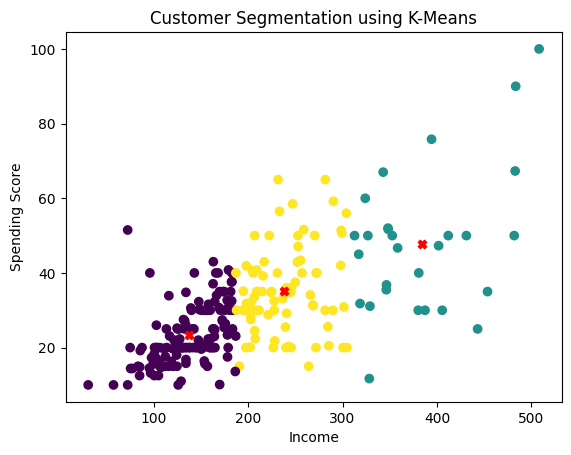

In [4]:
import matplotlib.pyplot as plt

plt.scatter(X['Income'], X['Spending'], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], color='red', marker='X')

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")

plt.show()